<a href="https://colab.research.google.com/github/julschleinitz/ai4chemistry-bootcamp/blob/main/tutorials/molecular-representations.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Tutorial 1 — Molecular Representations
## AI for Chemical Sciences Bootcamp · Caltech, August 2026

**Instructor:** Jules Schleinitz  
**Estimated time:** 60 min

---

### What you will learn

How you encode a molecule determines what a model can learn. In this tutorial we build and compare several representations of the same molecules — from your own hand-designed features to RDKit descriptors, fingerprints, and graphs — and explore them visually on the **ESOL aqueous solubility** dataset.

| Step | Section | What you'll do |
|------|---------|-----------------|
| 1 | Dataset | Load and explore the ESOL solubility data |
| 2 | Visualization toolkit | Build one reusable tool that projects any representation to 2D and plots it interactively |
| 3 | Design your own representation | Hypothesize which molecular properties drive solubility and code them up yourself |
| 4–6 | Representations | Build RDKit descriptors (+ charge/pKa), Morgan fingerprints, and a molecular graph |
| 7 | Preview | Fit a simple Ridge regression model — full modeling (Random Forests, neural networks, GNNs) is covered in later lectures |

By the end you will understand how different representations encode the same molecule, be able to visualize their chemical space interactively, and see a first, minimal example of turning a representation into a prediction.

---
## 0. Setup

In [ ]:
# Install dependencies (Colab only — comment out if running locally)
!pip install rdkit torch torch-geometric deepchem pandas scikit-learn matplotlib seaborn bokeh -q

In [ ]:
import base64
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# RDKit
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem, rdMolDescriptors, rdFingerprintGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit import DataStructs

# Scikit-learn
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# PyTorch / PyTorch Geometric (used to build the graph representation later)
import torch
from torch_geometric.data import Data

# Bokeh (interactive chemical-space plots)
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource, HoverTool, LinearColorMapper, ColorBar
from bokeh.palettes import Viridis256

output_notebook()

print("All imports OK")

---
## 1. Dataset — ESOL aqueous solubility

The **ESOL** dataset (Delaney, 2004) contains measured aqueous solubility (log mol/L) for 1,128 small organic molecules. It is one of the most widely used benchmarks for molecular property prediction.

**Target:** `measured log(solubility:mol/L)` — a continuous value, so this is a regression task.

> **Why solubility?** It is directly relevant to drug formulation and agrochemistry, and it depends on a mix of electronic, steric, and hydrogen-bonding features — a good test for different representations.

In [36]:
# Load ESOL directly from DeepChem's MoleculeNet
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='Raw', splitter='scaffold')
train_ds, val_ds, test_ds = datasets

# Convert to a flat DataFrame for easier manipulation
# featurizer='Raw' puts RDKit Mol objects in ds.X, not SMILES strings —
# ds.ids holds the original SMILES regardless of featurizer, so use that.
def dataset_to_df(ds):
    smiles = list(ds.ids)
    y = ds.y.flatten()
    return pd.DataFrame({'smiles': smiles, 'logS': y})

df_train = dataset_to_df(train_ds)
df_val   = dataset_to_df(val_ds)
df_test  = dataset_to_df(test_ds)
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f"Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")
df_train.head()

Train: 902  Val: 113  Test: 113


,smiles,logS
0,CC(C)=CCCC(C)=CC(=O),0.390413
1,CCCC=C,0.090421
2,CCCCCCCCCCCCCC,-2.464346
3,CC(C)Cl,0.704920
4,CCC(C)CO,1.159746


### A Quick Tour of RDKit — Molecules, Visualization, and Descriptors

Everything in this notebook starts from a **SMILES string** (e.g. `CC(=O)O` for acetic acid) and turns it into an RDKit `Mol` object — RDKit's central data structure for a molecule (atoms, bonds, and all their properties). Almost every RDKit function takes a `Mol`, not a SMILES string directly, so `Chem.MolFromSmiles(...)` is the first line of nearly everything we do below.

Once you have a `Mol`, you can:
- **Inspect it**: iterate over `mol.GetAtoms()` / `mol.GetBonds()`, or compute properties like molecular formula (`rdMolDescriptors.CalcMolFormula`).
- **Draw it**: `Draw.MolToImage(mol)` for a single molecule, `Draw.MolsToGridImage([...])` for several at once (we'll use this a few cells down).
- **Compute descriptors on it**: the `rdkit.Chem.Descriptors` module implements ~200 physicochemical descriptors (molecular weight, LogP, TPSA, H-bond counts, ring counts, ...) as plain functions that take a `Mol` and return a number. This is the module behind the "Representation 1" section later in this notebook.

**Finding things in RDKit's documentation:** RDKit's API is large and not always intuitively organized, so it helps to know a few ways to search it:
- The [Getting Started in Python](https://www.rdkit.org/docs/GettingStartedInPython.html) page and the [RDKit Cookbook](https://www.rdkit.org/docs/Cookbook.html) cover most common tasks (reading/writing molecules, drawing, substructure search, descriptors, fingerprints) with runnable examples.
- The full [API reference](https://www.rdkit.org/docs/api/rdkit-pysrc.html) documents every module — but in practice, `dir(module)` and `help(function)` directly in Python/Jupyter (e.g. `help(Descriptors.MolLogP)`) is often the fastest way to see what's available and what it returns.
- To see *every* available descriptor at once, use `Descriptors._descList` (a list of `(name, function)` pairs) or `Descriptors.CalcMolDescriptors(mol)` (computes all of them for one molecule and returns a dict) — demonstrated below.
- If you know roughly what you want but not the exact function name, searching "rdkit &lt;concept&gt;" (e.g. "rdkit number of rings", "rdkit remove stereochemistry") usually surfaces the right function faster than browsing the reference alphabetically.

In [ ]:
# --- SMILES -> Mol -> inspect -> draw ---
example_smiles = df_train['smiles'].iloc[0]
mol = Chem.MolFromSmiles(example_smiles)

print(f"SMILES:            {example_smiles}")
print(f"Molecular formula: {rdMolDescriptors.CalcMolFormula(mol)}")
print(f"Number of atoms:   {mol.GetNumAtoms()} (heavy atoms only — RDKit hides Hs by default)")
print(f"Number of bonds:   {mol.GetNumBonds()}")
print(f"Atom symbols:      {[atom.GetSymbol() for atom in mol.GetAtoms()]}")

Draw.MolToImage(mol, size=(300, 200))

In [ ]:
# --- The Descriptors module: ~200 physicochemical descriptors, one function each ---
print(f"Descriptors.MolWt(mol)  = {Descriptors.MolWt(mol):.2f}")
print(f"Descriptors.MolLogP(mol) = {Descriptors.MolLogP(mol):.2f}")
print(f"Descriptors.TPSA(mol)    = {Descriptors.TPSA(mol):.2f}")

# `_descList` holds every (name, function) pair RDKit ships — useful for browsing what's available
print(f"\nRDKit ships {len(Descriptors._descList)} descriptor functions in total, e.g.:")
for name, fn in Descriptors._descList[:5]:
    print(f"  {name:20s} -> {fn(mol):.3f}")

# Or compute all of them at once for a given molecule:
all_descriptors = Descriptors.CalcMolDescriptors(mol)
print(f"\nCalcMolDescriptors(mol) returns a dict with {len(all_descriptors)} entries, e.g.:")
{k: round(v, 3) for k, v in list(all_descriptors.items())[:5]}

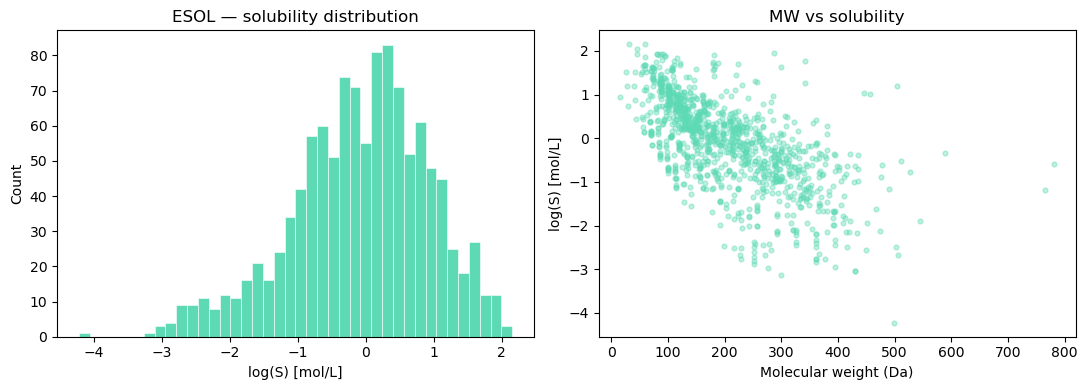

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df_all['logS'], bins=40, color='#5DDAB4', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('log(S) [mol/L]')
axes[0].set_ylabel('Count')
axes[0].set_title('ESOL — solubility distribution')

# Molecular weight vs solubility
mws = []
for smi in df_all['smiles']:
    mol = Chem.MolFromSmiles(smi)
    mws.append(Descriptors.MolWt(mol) if mol else np.nan)
axes[1].scatter(mws, df_all['logS'], alpha=0.4, s=12, c='#5DDAB4')
axes[1].set_xlabel('Molecular weight (Da)')
axes[1].set_ylabel('log(S) [mol/L]')
axes[1].set_title('MW vs solubility')

plt.tight_layout()
plt.show()

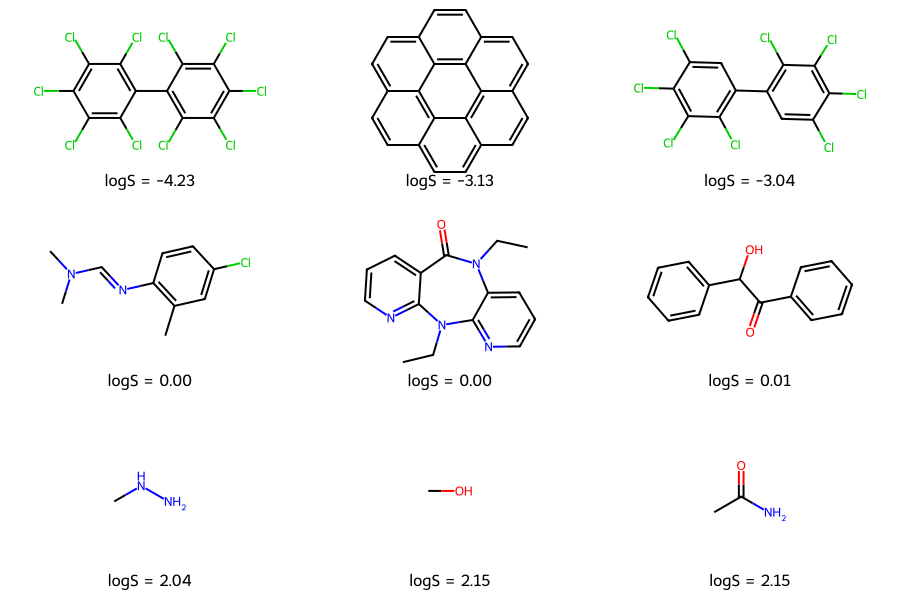

In [38]:
# Visualise a few molecules from each solubility range
df_sorted = df_all.sort_values('logS')
examples = pd.concat([
    df_sorted.head(3),            # poorly soluble
    df_sorted.iloc[len(df_sorted)//2 - 1 : len(df_sorted)//2 + 2],  # medium
    df_sorted.tail(3)             # highly soluble
])

mols  = [Chem.MolFromSmiles(s) for s in examples['smiles']]
labels = [f"logS = {v:.2f}" for v in examples['logS']]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 200), legends=labels)
img

---
## 2. A Tool for Visualizing Chemical Space

A **representation** turns a molecule into numbers a computer can work with. Different representations capture different information — so a natural way to compare them is to project each one down to 2D and look at how it arranges the same set of molecules.

We'll build **one reusable function**, `plot_chemical_space`, that:
1. Takes any fixed-length representation matrix (one row per molecule),
2. Projects it to 2D with **PCA** (the same idea introduced in Lecture 2),
3. Plots it as an **interactive** scatter, colored by solubility, where hovering over a point shows the molecule's structure.

We'll reuse this exact function for every representation we build in this notebook — including one you design yourself. Change the representation, rerun the plot, and see how the chemical space rearranges.

In [ ]:
def mol_to_base64_png(mol, size=(150, 100)):
    """Render an RDKit Mol to a base64-encoded PNG data URI, for embedding in a Bokeh tooltip."""
    img = Draw.MolToImage(mol, size=size)
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    return 'data:image/png;base64,' + base64.b64encode(buf.getvalue()).decode('utf-8')

In [ ]:
# Precompute structure images for a fixed subsample once — images only depend on the
# molecule's structure (never on the representation), so every later plot reuses this cache.
N_BOKEH = 400
bokeh_idx = df_all.sample(N_BOKEH, random_state=42).index

MOL_IMAGES = {}
for i in bokeh_idx:
    mol = Chem.MolFromSmiles(df_all.loc[i, 'smiles'])
    MOL_IMAGES[i] = mol_to_base64_png(mol) if mol else ''

print(f"Cached structure images for {len(MOL_IMAGES)} molecules")

In [ ]:
def project_2d(X, method='pca', n_components=2, random_state=42):
    """Project a representation matrix to `n_components` dimensions."""
    X = np.nan_to_num(np.asarray(X, dtype=float))
    if method == 'pca':
        pca = PCA(n_components=n_components, random_state=random_state)
        coords = pca.fit_transform(X)
        print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
        return coords
    raise NotImplementedError(
        f"method='{method}' is not implemented — only 'pca' is available for now. "
        "This is a good place to add a t-SNE or UMAP branch later."
    )

In [ ]:
def plot_chemical_space(X, df=None, idx=None, color_col='logS', title='Chemical space'):
    """Project `X` to 2D and show it as an interactive, hover-to-see-structure Bokeh scatter.

    `X` must have one row per molecule in `df`'s order (default: df_all). Only the
    molecules in `idx` (default: the precomputed bokeh_idx subsample) are drawn, so
    that structure images can be reused from the MOL_IMAGES cache.
    """
    if df is None:
        df = df_all
    if idx is None:
        idx = bokeh_idx
    if len(X) != len(df):
        raise ValueError(f"X has {len(X)} rows but df has {len(df)} — they must be aligned 1:1")

    coords = project_2d(X)
    sub = df.loc[idx]

    source = ColumnDataSource(data=dict(
        x=coords[idx, 0],
        y=coords[idx, 1],
        smiles=sub['smiles'],
        logS=sub['logS'],
        color_val=sub[color_col],
        image=[MOL_IMAGES[i] for i in idx],
    ))

    mapper = LinearColorMapper(palette=Viridis256, low=sub[color_col].min(), high=sub[color_col].max())

    p = figure(title=title, width=650, height=500, tools='pan,wheel_zoom,reset,save')
    p.circle('x', 'y', source=source, size=8, alpha=0.7,
              fill_color={'field': 'color_val', 'transform': mapper}, line_color=None)
    p.add_layout(ColorBar(color_mapper=mapper, title=color_col), 'right')

    hover = HoverTool(tooltips="""
        <div>
            <img src="@image" style="width:120px;height:80px;"><br>
            <span><b>SMILES:</b> @smiles</span><br>
            <span><b>logS:</b> @logS{0.2f}</span><br>
            <span><b>""" + color_col + """:</b> @color_val{0.2f}</span>
        </div>
    """)
    p.add_tools(hover)
    p.xaxis.axis_label = 'PC1'
    p.yaxis.axis_label = 'PC2'
    show(p)

In [ ]:
# Quick demo: a trivial 2-feature "representation" — molecular weight + heavy-atom count —
# just to check the pipeline works before we use it on anything more interesting.
demo_rows = []
for smi in df_all['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        demo_rows.append([Descriptors.MolWt(mol), mol.GetNumHeavyAtoms()])
    else:
        demo_rows.append([np.nan, np.nan])
X_demo = np.array(demo_rows)

plot_chemical_space(X_demo, title='Demo: MolWt + heavy-atom count')

---
## 3. Design Your Own Representation

Before looking at what RDKit or the literature suggests, take another look at the molecules you drew earlier (poorly soluble vs. highly soluble). **What do you think drives aqueous solubility?**

Pick 2–4 molecular properties you'd expect to matter — for example: molecule size, polarity, hydrogen-bonding capacity, aromaticity, or charge — and briefly write down *why* for each one.

Then implement `compute_custom_features` below to turn each SMILES string into a small vector of your chosen properties, and feed it straight into `plot_chemical_space`. You don't need RDKit's full descriptor set — simple counts (e.g. number of oxygens, number of rings, number of rotatable bonds) are enough to start.

In [ ]:
def compute_custom_features(smiles_list):
    """Your turn: return one feature vector per SMILES. Replace/extend the example below."""
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan, np.nan])
            continue
        # Example starting point — replace with properties YOU think matter:
        num_oxygens = sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'O')
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        rows.append([num_oxygens, num_rings])
    return np.array(rows)

X_custom = compute_custom_features(df_all['smiles'])
plot_chemical_space(X_custom, title='My representation')

Compare your hypotheses to the expert-crafted descriptor set below — how many did you anticipate? What did you miss?

---
## 4. Representation 1 — Physicochemical descriptors

The simplest approach: compute a fixed set of expert-designed features from the 2D structure.

RDKit exposes ~200 descriptors. We will use a curated subset that directly captures solubility-relevant properties:

| Descriptor | Chemical meaning |
|-----------|------------------|
| `MolLogP` | Lipophilicity (Wildman-Crippen) |
| `MolWt` | Molecular weight |
| `NumHDonors` / `NumHAcceptors` | H-bond capacity |
| `TPSA` | Topological polar surface area |
| `NumRotatableBonds` | Flexibility |
| `RingCount` | Aromaticity proxy |

These correspond to the features used in Delaney's original rule-based model.

In [39]:
DESCRIPTOR_FNS = {
    'MolLogP':           Descriptors.MolLogP,
    'MolWt':             Descriptors.MolWt,
    'NumHDonors':        rdMolDescriptors.CalcNumHBD,
    'NumHAcceptors':     rdMolDescriptors.CalcNumHBA,
    'TPSA':              Descriptors.TPSA,
    'NumRotatableBonds': rdMolDescriptors.CalcNumRotatableBonds,
    'RingCount':         Descriptors.RingCount,
    'FractionCSP3':      rdMolDescriptors.CalcFractionCSP3,
}

def compute_descriptors(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * len(DESCRIPTOR_FNS))
        else:
            rows.append([fn(mol) for fn in DESCRIPTOR_FNS.values()])
    return pd.DataFrame(rows, columns=list(DESCRIPTOR_FNS.keys()))

X_desc_train = compute_descriptors(df_train['smiles'])
X_desc_val   = compute_descriptors(df_val['smiles'])
X_desc_test  = compute_descriptors(df_test['smiles'])

print(X_desc_train.shape)
X_desc_train.head()

(902, 8)


,MolLogP,MolWt,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,RingCount,FractionCSP3
0,2.8780,152.237,0,1,17.07,4,0,0.5
1,1.9725,70.135,0,0,0.00,2,0,0.6
2,5.7074,198.394,0,0,0.00,11,0,1.0
3,1.6336,78.542,0,0,0.00,0,0,1.0
4,1.0248,88.150,1,1,20.23,2,0,1.0


### Representation 1b — Charge & protonation state

Solubility is strongly affected by whether a molecule is charged or has groups that can gain/lose a proton at physiological pH. We add two kinds of features:

- **Formal charge** and a coarse **ionizable-group count** — computed directly from the SMILES with RDKit (a few SMARTS patterns for carboxylic acids, amines, phenols, anilines). This is a heuristic, not a real pKa prediction.
- **pKa**, joined in from a precomputed dataset (`tutorials/data/esol_pka.csv`) keyed by canonical SMILES. **This file currently ships with only a handful of illustrative rows — replace it with the instructor's real pKa predictions before class.** Molecules without a match keep `pka` as missing (`has_pka_data = 0`), imputed with the training-set median only when building the model input (no test-set leakage).

In [ ]:
# --- Charge & ionizable-group heuristic (RDKit only) ---
IONIZABLE_PATTERNS = {
    'carboxylic_acid': Chem.MolFromSmarts('C(=O)[OH]'),
    'phenol':          Chem.MolFromSmarts('c[OH]'),
    'primary_amine':   Chem.MolFromSmarts('[NX3;H2;!$(NC=O)]'),
    'secondary_amine': Chem.MolFromSmarts('[NX3;H1;!$(NC=O)]'),
    'aniline':         Chem.MolFromSmarts('c[NX3]'),
}

def canonical_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else None

def charge_features(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {'FormalCharge': np.nan, 'NumIonizableGroups': np.nan}
    n_ionizable = sum(len(mol.GetSubstructMatches(patt)) for patt in IONIZABLE_PATTERNS.values())
    return {'FormalCharge': float(Chem.GetFormalCharge(mol)), 'NumIonizableGroups': float(n_ionizable)}

def add_charge_features(df):
    feats = pd.DataFrame([charge_features(s) for s in df['smiles']], index=df.index)
    return pd.concat([df, feats], axis=1)

# --- pKa enrichment (instructor-supplied CSV, keyed by canonical SMILES) ---
pka_df = pd.read_csv('data/esol_pka.csv')
pka_df['smiles_canonical'] = pka_df['smiles'].apply(canonical_smiles)
pka_df = pka_df.drop_duplicates(subset='smiles_canonical')

def merge_pka(df):
    df = df.copy()
    df['smiles_canonical'] = df['smiles'].apply(canonical_smiles)
    merged = df.merge(pka_df[['smiles_canonical', 'pka', 'is_ionizable']], on='smiles_canonical', how='left')
    n_matched = int(merged['pka'].notna().sum())
    print(f"pKa merge: {n_matched}/{len(merged)} matched, {len(merged) - n_matched} unmatched (kept as NaN)")
    merged['has_pka_data'] = merged['pka'].notna().astype(int)
    merged['is_ionizable'] = merged['is_ionizable'].fillna(0).astype(int)
    return merged.drop(columns=['smiles_canonical'])

df_train = add_charge_features(merge_pka(df_train))
df_val   = add_charge_features(merge_pka(df_val))
df_test  = add_charge_features(merge_pka(df_test))
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Model-input block: same numeric columns, pKa imputed with the TRAIN median only (no leakage)
pka_median = df_train['pka'].median()

def build_charge_block(df):
    block = df[['FormalCharge', 'NumIonizableGroups', 'has_pka_data']].reset_index(drop=True).copy()
    block['pka'] = df['pka'].fillna(pka_median).reset_index(drop=True)
    return block

X_desc_train = pd.concat([X_desc_train, build_charge_block(df_train)], axis=1)
X_desc_val   = pd.concat([X_desc_val,   build_charge_block(df_val)],   axis=1)
X_desc_test  = pd.concat([X_desc_test,  build_charge_block(df_test)],  axis=1)

print(X_desc_train.shape)
X_desc_train.head()

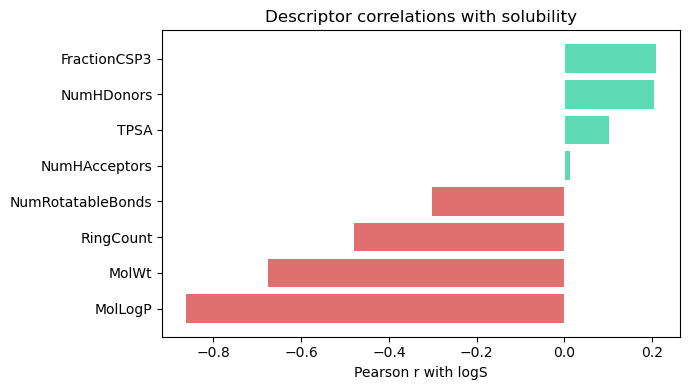

In [40]:
# Correlation of each descriptor with logS
corr_df = X_desc_train.copy()
corr_df['logS'] = df_train['logS'].values
corr = corr_df.corr()['logS'].drop('logS').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#E07070' if v < 0 else '#5DDAB4' for v in corr]
ax.barh(corr.index, corr.values, color=colors, edgecolor='none')
ax.axvline(0, color='white', lw=0.8)
ax.set_xlabel('Pearson r with logS')
ax.set_title('Descriptor correlations with solubility')
plt.tight_layout()
plt.show()

In [ ]:
X_desc_all = np.vstack([X_desc_train.values, X_desc_val.values, X_desc_test.values])
plot_chemical_space(X_desc_all, title='Descriptor space (incl. charge/pKa)')

---
## 5. Representation 2 — Morgan fingerprints (ECFP4)

Morgan fingerprints encode the **local chemical environment** of each atom out to a given radius. With radius=2 and 2048 bits they are known as **ECFP4**.

```
Molecule → iterate atom environments (radius 0,1,2) → hash → fold to 2048-bit vector
```

Key properties:
- **Fixed-length** bit vector (or count vector)
- **No explicit bond-order/chirality** by default (configurable)
- **Sparse** — typically <5% of bits set
- Highly effective for similarity search and ML baselines

In [42]:
def morgan_matrix(smiles_list, radius=2, n_bits=2048):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = generator.GetFingerprint(mol)
            arr = np.zeros(n_bits, dtype=np.uint8)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
        else:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
    return np.array(fps)

X_fp_train = morgan_matrix(df_train['smiles'])
X_fp_val   = morgan_matrix(df_val['smiles'])
X_fp_test  = morgan_matrix(df_test['smiles'])

print(f"Fingerprint matrix shape: {X_fp_train.shape}")
print(f"Average bit density: {X_fp_train.mean()*100:.1f}%")

Fingerprint matrix shape: (902, 2048)
Average bit density: 1.0%


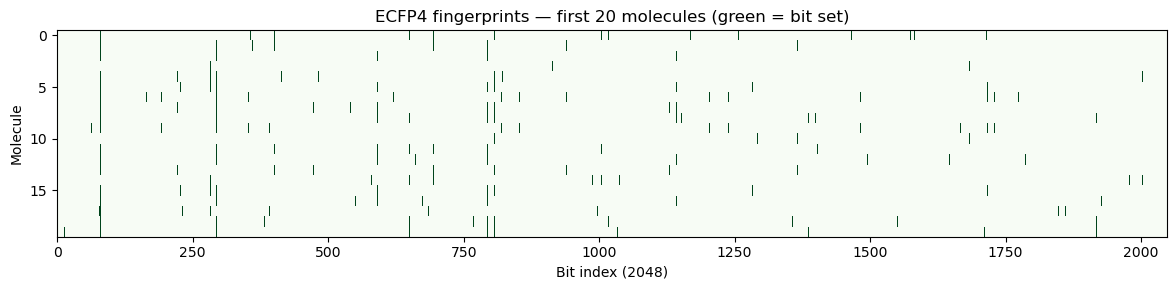

In [45]:
# Visualise the fingerprint sparsity for the first 20 molecules
fig, ax = plt.subplots(figsize=(12, 3))
ax.imshow(X_fp_train[:20], aspect='auto', cmap='Greens', interpolation='nearest')
ax.set_xlabel('Bit index (2048)')
ax.set_ylabel('Molecule')
ax.set_title('ECFP4 fingerprints — first 20 molecules (green = bit set)')
plt.tight_layout()
plt.show()

In [ ]:
X_fp_all = np.vstack([X_fp_train, X_fp_val, X_fp_test])
plot_chemical_space(X_fp_all, title='Fingerprint space (ECFP4)')

---
## 6. Representation 3 — Molecular graph

Instead of hashing atom environments into a fixed vector, we represent the molecule **as-is**: atoms are nodes, bonds are edges.

```
Molecule → atoms (node features) + bonds (edge indices) → Graph
```

### Node features (per atom)
| Feature | Values |
|---------|--------|
| Atomic number | one-hot (C, N, O, S, F, Cl, Br, other) |
| Degree | 0–5 |
| Formal charge | int |
| Hybridization | SP, SP2, SP3 |
| Aromaticity | 0/1 |
| Num H | 0–4 |

Unlike the previous two representations, a graph has no fixed-size vector — the number of nodes and edges varies per molecule — so it doesn't fit into `plot_chemical_space` (PCA needs equal-length rows). We build the representation here and stop: **training a model that consumes it — a GNN with graph convolutions and pooling — is covered in Lecture 5 (GNNs/MLIPs)**. Come back to `graph_train`/`graph_val`/`graph_test` then.

> **Key difference from fingerprints:** a GNN *learns* which structural patterns matter for the property, rather than using predetermined hash buckets — but it needs to be trained to do that.

In [51]:
ATOM_TYPES = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'other']

def atom_features(atom):
    """Return a 1D feature vector for a single atom."""
    # Atom type one-hot
    sym = atom.GetSymbol()
    atom_oh = [int(sym == t) for t in ATOM_TYPES[:-1]] + [int(sym not in ATOM_TYPES[:-1])]
    # Degree (capped at 5)
    degree_oh = [int(atom.GetDegree() == d) for d in range(6)]
    # Hybridization
    hyb = atom.GetHybridization()
    hyb_oh = [
        int(hyb == Chem.rdchem.HybridizationType.SP),
        int(hyb == Chem.rdchem.HybridizationType.SP2),
        int(hyb == Chem.rdchem.HybridizationType.SP3),
    ]
    # Scalar features
    scalars = [
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]
    return atom_oh + degree_oh + hyb_oh + scalars

NODE_DIM = len(atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0)))
print(f"Node feature dimension: {NODE_DIM}")

def smiles_to_graph(smi, y_val):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    # Node features
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    # Edge indices (undirected → add both directions)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    if edges:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    y = torch.tensor([y_val], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, y=y)

# Build graph datasets
graph_train = [g for g in (smiles_to_graph(s, y) for s, y in zip(df_train['smiles'], df_train['logS'])) if g]
graph_val   = [g for g in (smiles_to_graph(s, y) for s, y in zip(df_val['smiles'],   df_val['logS']))   if g]
graph_test  = [g for g in (smiles_to_graph(s, y) for s, y in zip(df_test['smiles'],  df_test['logS']))  if g]

print(f"Graph train: {len(graph_train)}  val: {len(graph_val)}  test: {len(graph_test)}")
print(f"Example graph: {graph_train[0]}")

Node feature dimension: 22
Graph train: 902  val: 113  test: 113
Example graph: Data(x=[11, 22], edge_index=[2, 20], y=[1])


---
## 7. Preview — From Representation to Prediction

So far we've only built and visualized representations — no model has seen the solubility labels yet. As a small preview of what's coming in later lectures (Supervised Learning, Neural Networks, GNNs), let's fit the simplest possible model, **Ridge regression**, on the descriptor representation (including the charge/pKa features) we built above.

In [ ]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
ridge.fit(X_desc_train, df_train['logS'])

y_pred_ridge = ridge.predict(X_desc_test)
rmse_ridge = root_mean_squared_error(df_test['logS'], y_pred_ridge)
r2_ridge   = r2_score(df_test['logS'], y_pred_ridge)

print(f"Ridge regression (descriptors) — Test RMSE: {rmse_ridge:.3f}  R²: {r2_ridge:.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
y_true = df_test['logS'].values
ax.scatter(y_true, y_pred_ridge, alpha=0.5, s=18, c='#5DDAB4')
lim = [min(y_true.min(), y_pred_ridge.min()) - 0.3, max(y_true.max(), y_pred_ridge.max()) + 0.3]
ax.plot(lim, lim, 'w--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Measured logS')
ax.set_ylabel('Predicted logS')
ax.set_title('Ridge (descriptors + charge/pKa) — test set')
plt.tight_layout()
plt.show()

---
## 8. Discussion

### Discussion

| Representation | Strengths | Limitations |
|---------------|-----------|-------------|
| Physicochemical descriptors (+ charge/pKa) | Interpretable, fast, domain-informed | Fixed feature set; misses structural patterns not encoded |
| Morgan fingerprints | Captures local environments, widely validated | Bit collisions; no spatial awareness; fixed radius |
| Molecular graph | Flexible, no information loss — atoms and bonds kept as-is | No fixed-size vector — needs a model like a GNN to consume it directly (Lecture 5) |

**Scaffold split note:** we used a scaffold split (Bemis-Murcko), which is harder than random split — models must generalise to new chemical scaffolds. The Ridge RMSE above is therefore higher than often reported in the literature for a random split.

---
## 9. Exercises

### Easy
1. Change the Morgan fingerprint radius from 2 to 3 (ECFP6) and rerun `plot_chemical_space` on the fingerprint space. How does the 2D map shift?
2. Add `NumAromaticRings` and `NumAliphaticRings` to the descriptor set. How does Ridge regression change?
3. Compare the `explained_variance_ratio_` printed for the descriptor-space and fingerprint-space plots — which representation compresses better to 2D?
4. Recolor any `plot_chemical_space` call by passing `color_col='MolWt'` or `color_col='NumIonizableGroups'` instead of `logS`. Does a different property explain the same clusters?

### Medium
5. The graph representation built above has no edge (bond-type) features — bonds are just adjacency. Once you've covered GNNs in Lecture 5, come back and add single/double/aromatic bond features to `smiles_to_graph`. For now, sketch what you'd add and why.

### Challenge
6. Compute a **Tanimoto similarity matrix** between the 30 least-soluble molecules and the 30 most-soluble ones using ECFP4. Visualise as a heatmap. What does it tell you about the chemical space of solubility?
7. Extend `compute_custom_features` with 2–3 more properties and see whether your representation's 2D map starts to resemble the RDKit descriptor map.

In [ ]:
# Your code here


---
## Further Reading

- **Rogers & Hahn (2010)** — *Extended-Connectivity Fingerprints* — J. Chem. Inf. Model. 50, 742 — the ECFP reference
- **Duvenaud et al. (2015)** — *Convolutional Networks on Graphs for Learning Molecular Fingerprints* — NeurIPS
- **Yang et al. (2019)** — *Analyzing Learned Molecular Representations for Property Prediction* — J. Chem. Inf. Model. 59, 3370 (Chemprop paper — benchmarks fingerprints vs graphs on MoleculeNet)
- **David et al. (2020)** — *Molecular Representations in AI-driven Drug Discovery* — J. Cheminform. 12, 56 — accessible review
- **Delaney (2004)** — *ESOL: Estimating Aqueous Solubility Directly from Molecular Structure* — J. Chem. Inf. Comput. Sci. 44, 1000 — original dataset paper
- **Pan et al. (2021)** — *MolGpKa: A Web Server for Small Molecule pKa Prediction Using a Graph-Convolutional Neural Network* — J. Chem. Inf. Model. 61, 3159 — an example pKa-prediction approach for enriching `esol_pka.csv`
- **Bokeh documentation** — [`HoverTool`](https://docs.bokeh.org/en/latest/docs/user_guide/interaction/tooltips.html) and [`ColumnDataSource`](https://docs.bokeh.org/en/latest/docs/user_guide/basic/data.html) — the two APIs behind `plot_chemical_space`